In [10]:
import numpy as np
import matplotlib.pyplot as plt
# !pip install cartopy
# import cartopy
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
import pickle

# Load the pkl file
with open('PNA_region.pkl', 'rb') as file:
    data = pickle.load(file)


print(data['PC dimension'])
print(data['EOF dimension'])

PC  = data['PC']
EOF = data['EOF']
lat = data['lat']
lon = data['lon']



10 ensembles, 20 years, 12 months, 8 initialization (for each month), 47 lead time, 10 modes
10 modes, 20<lat<80, 100<lon<300


In [3]:
# prepare coordinate
lat_dim, lon_dim  = np.where((lon>100)&(lon<300) & (lat>20)&(lat<80))
x                 = lon[lat_dim.min():lat_dim.max()+1,lon_dim.min():lon_dim.max()+1]
y                 = lat[lat_dim.min():lat_dim.max()+1,lon_dim.min():lon_dim.max()+1]

In [16]:
PC.shape

(10, 20, 12, 8, 47, 10)

# visualize data 

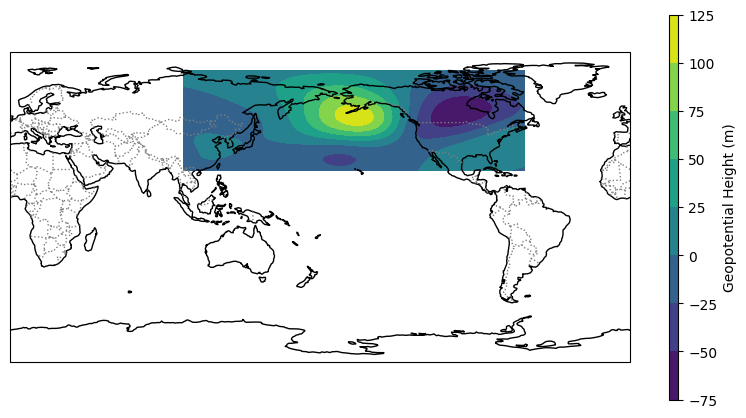

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set up the map projection and the plot
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Add coastlines and optional features
ax.coastlines()  # Adds the coastline
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')  # Optional: adds country borders
# ax.add_feature(cfeature.LAND, color='lightgray')  # Optional: fills land areas
# ax.add_feature(cfeature.OCEAN, color='lightblue')  # Optional: fills ocean areas
sc = ax.contourf(x-180,y,EOF[0,:,:])

# Set the extent (longitude, latitude) of the plot
ax.set_extent([-180, 180, -90, 90])  # Adjust as needed for your area
cbar = plt.colorbar(sc, orientation='vertical', pad=0.05, aspect=40)
cbar.set_label('Geopotential Height (m)')



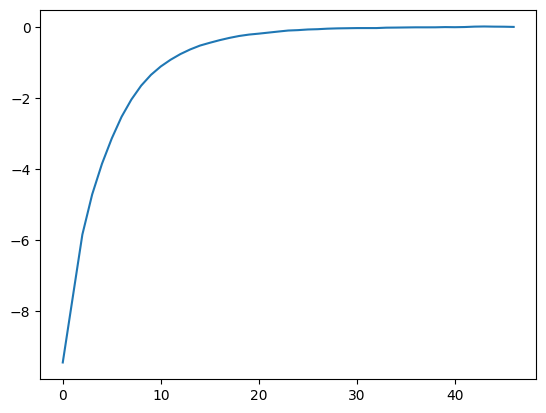

In [9]:
## error growth

## autocorrelation test
mode         = 1

dim          = PC[...,mode].shape
realizations = PC[...,mode].size
tmp          = PC[...,mode].reshape([int(realizations/dim[-1]),dim[-1]])

plt.figure()
series = np.mean(np.var(PC,axis=0)[:,:,:,:,mode],axis=(0,1,2)) # calculate ensemble variance
plt.plot(np.log(series/np.mean(series[30:])))



# Calculate predictable component 
## Step 1: Calculate the area between gray line and curve (Loi et al. 2024)
![image info](./APT_Schm.png)

## Step 2: Calculate eigenvalue and eigenvectors of the covariance matrix. Where column vector is the corresponding eigen vector. Eigenvalue represents how long such pattern stay predictable 

## Step 3: Plot!